In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

# co-expression network analysis packages:
library(WGCNA)
library(hdWGCNA)

# enable parallel processing for network analysis (optional)
enableWGCNAThreads(nThreads = 8)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Allowing parallel execution with up to 8 working processes.


In [3]:
# load the scRNAseq dataset
scObj_query <- readRDS(file.path('./../data/HGSOC_All.rds'))
print(scObj_query)
print(table(scObj_query@meta.data$Groups))

An object of class Seurat 
27157 features across 159682 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

   Primary Tumor Metastatic Tumor       Lymph Node          Ascites 
           45146            21561            26449            38206 
            PBMC 
           28320 


In [4]:
scObj_query <- ScaleData(scObj_query, assay = "RNA")
scObj_query <- RunHarmony(scObj_query, group.by.vars=c('Patients'))
scObj_query

Centering and scaling data matrix

Warning message:
“Command ScaleData.RNA changing from SeuratCommand to SeuratCommand”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7984100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7984100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7984100)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations



An object of class Seurat 
27157 features across 159682 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [5]:
# Select Primary tumor cells
filtered_barcode_index <- rownames(filter(scObj_query@meta.data, Groups == "Primary Tumor" ))
scObj_query <- subset(scObj_query, cells = filtered_barcode_index)
scObj_query@meta.data <- droplevels(scObj_query@meta.data)
print(scObj_query)
print(table(scObj_query@meta.data$maintypes))

An object of class Seurat 
27157 features across 45146 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

    Stromal cells Endothelial cells      Cancer cells     Myeloid cells 
             5209               599             24849              8015 
   Lymphoid cells 
             6474 


In [6]:
# Select Cancer cells
filtered_barcode_index <- rownames(filter(scObj_query@meta.data, maintypes == "Cancer cells" ))
scObj_query <- subset(scObj_query, cells = filtered_barcode_index)
scObj_query@meta.data <- droplevels(scObj_query@meta.data)
print(scObj_query)
print(table(scObj_query@meta.data$Patients))

An object of class Seurat 
27157 features across 24849 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

 HGSOC1  HGSOC2  HGSOC3  HGSOC4  HGSOC5  HGSOC6  HGSOC7  HGSOC8  HGSOC9 HGSOC10 
   3281    7709     959    2843    3296    1784     969    1092    1230    1686 


In [7]:
# load the processed dataset
stObj_ref <- readRDS(file.path('./results/ST_tumor_hdWGCNA_object.rds'))
print(stObj_ref)
length(GetWGCNAGenes(stObj_ref))

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


[1] 11729

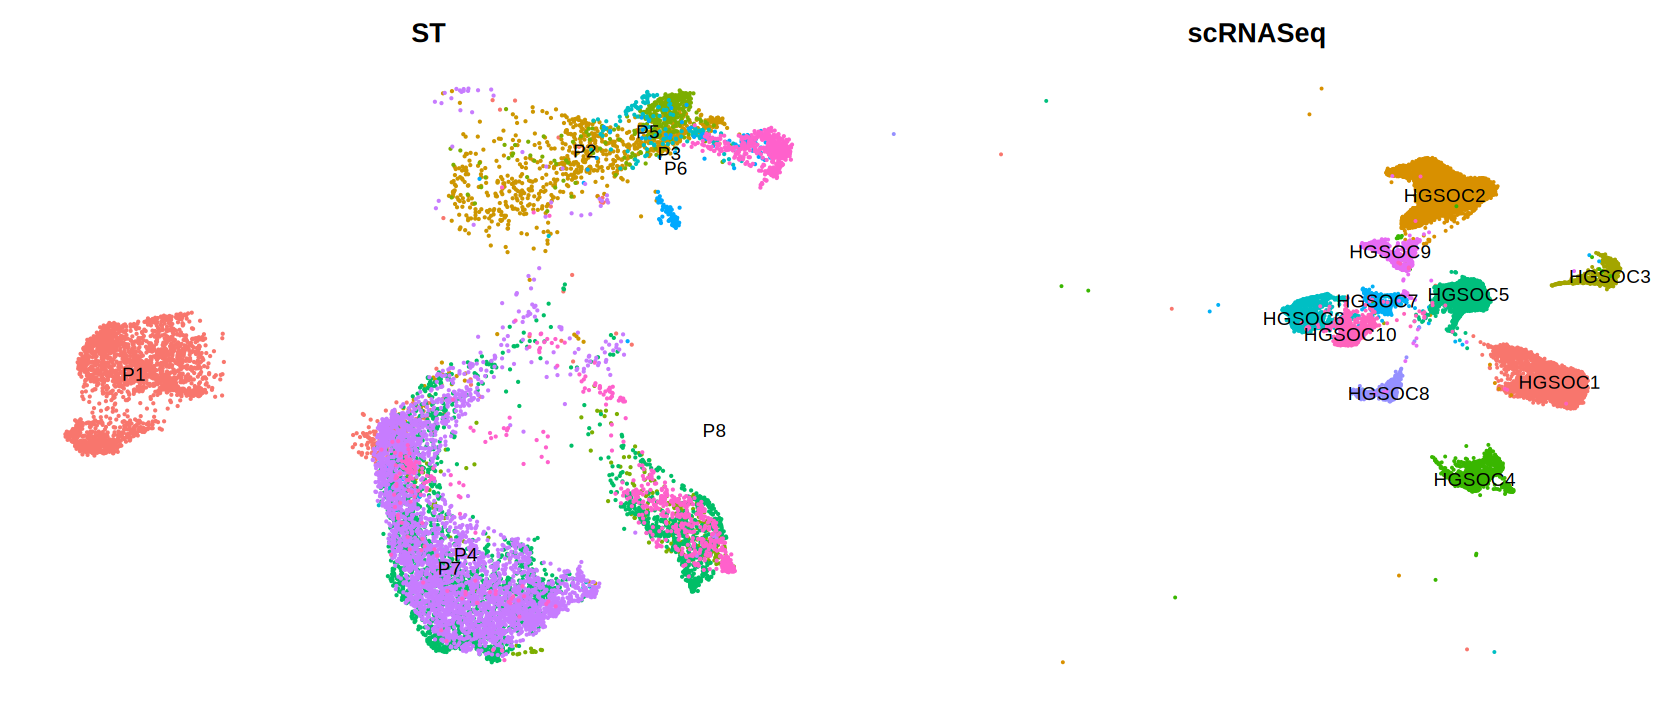

In [8]:
options(repr.plot.height = 6, repr.plot.width = 14)
p1 <- DimPlot(stObj_ref, group.by='patient', label=TRUE) +
   umap_theme() +
   ggtitle('ST') +
   NoLegend()

p2 <- DimPlot(scObj_query, group.by='Patients', label=TRUE) +
   umap_theme() +
   ggtitle('scRNASeq') +
   NoLegend()

p1 + p2

In [9]:
# Project modules from query to reference dataset
seurat_query <- ProjectModules(
  seurat_obj = scObj_query,
  seurat_ref = stObj_ref,
  # vars.to.regress = c(), # optionally regress covariates when running ScaleData
  group.by.vars = "Patients", # column in seurat_query to run harmony on
  wgcna_name_proj="projected", # name of the new hdWGCNA experiment in the query dataset
  wgcna_name = "HGSOC" # name of the hdWGCNA experiment in the ref dataset
)

Warning message in ProjectModules(seurat_obj = scObj_query, seurat_ref = stObj_ref, :
“The following modules will not be projected because too few genes are present in seurat_obj: ”


[1] "project modules"
[1] "Tumor-M1"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M1 to pcaTumorM1_”
pcaTumorM1_ 1 
Positive:  MMP23B, S100A4, CXCL12, FAM83A, PDPN, ADGRL2, PAX2, CALM3, FZD3, NREP 
	   MEOX1, MYRF, NPAS3, SYNDIG1, PTGS1, CRABP2, IMPG2, EFNB2, AFAP1L2, SH3PXD2A 
	   P3H3, RNF144A, COL4A2, SIRPA, COL6A1, AKAP6, PIEZO1, COL3A1, CPE, APOC1 
Negative:  HLA-C, HLA-B, HLA-A, B2M, HLA-DRB1, HLA-DRA, HLA-DPA1, HLA-E, BST2, HLA-DQA1 
	   TAP1, HLA-DPB1, HLA-DQB1, XAF1, PARP14, UBE2L6, C1S, HLA-F, PSAP, IFI35 
	   GBP1, GRN, LAP3, CD99, APOL6, CTSD, CXCL10, HLA-DMB, C1R, PTGDS 
pcaTumorM1_ 2 
Positive:  HLA-DPA1, HLA-DRB1, HLA-DRA, HLA-DQB1, UBE2L6, HLA-DPB1, CD99, HLA-DQA1, SPCS3, KLK11 
	   B2M, SH3BGRL3, BST2, CRABP2, ACTB, HLA-DMB, SDF2L1, KLK7, LCP1, UNC13D 
	   S100A4, HLA-DOA, LAP3, PTGDS, BNIPL, HLA-B, NR1H3, TNFAIP8, GSDMD, DERL3 
Negative:  BASP1, TLE1, COL6A1, LAMC1, EFNB2, ST14, ABCA1, IRX3, SN

[1] "grey"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcagrey to pcagrey_”
pcagrey_ 1 
Positive:  MTDH, PABPN1, MZT2B, LAPTM4B, UBXN4, EIF5, RSF1, ARPC2, CLDN7, MRPL57 
	   COX8A, FKBP2, GUK1, JTB, MT-ND2, TMEM219, COX5A, HEBP2, MT-ND3, PNISR 
	   PRELID1, TMEM179B, BRD2, ZC3H15, CRIP2, SYNGR2, PRPF40A, MFSD10, METTL5, NHP2 
Negative:  CCL21, CCL3, IGFBP7, RGS5, ALOX5AP, RGS1, CCL2, RARRES1, PLCXD3, PKHD1L1 
	   CFH, ADAMTS9, RAMP2, FTH1, SLC2A3, C15orf48, ITM2A, MEF2C, MTRNR2L12, S100A8 
	   S100A2, TMEM47, CDKN2C, HOXB-AS3, SCGB3A1, PHLDA1, SFRP4, CLDN5, GYPC, ITGA1 
pcagrey_ 2 
Positive:  S100A14, S100A16, CYC1, ABHD14B, C12orf57, NHP2, PRELID1, CD74, LY6E, NME2 
	   C1QBP, EIF5A, PFN1, GPX4, PCBD1, TXNDC17, HIGD2A, SEC11A, NGRN, EXOSC4 
	   TMED3, VDAC1, LAMTOR1, MAF1, APRT, COX5A, FAM162A, ALDOA, FIS1, TMEM256 
Negative:  KCNQ1OT1, RBP1, PRRC2B, MT-CO3, MT-ATP6, MT-ND4, CCNL1, REV3L, UGCG

...

Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M5 to pcaTumorM5_”
pcaTumorM5_ 1 
Positive:  NDUFB9, CNBP, P4HB, ANAPC11, EPCAM, BCAP31, TSPAN3, LMAN2, AUP1, PPIB 
	   EMC4, SERF2, VPS28, SOD1, IAH1, LGALS3BP, NDUFS5, SUMO2, GRINA, MRPS26 
	   FUNDC2, RPS17, CST3, SERBP1, RBCK1, COX6A1, MMADHC, OST4, TOMM20, RAD23A 
Negative:  XPR1, DUSP4, PREX2, HCLS1, ESR1, GDF15, CD55, LINC01436, PEG10, THY1 
	   EPB41L2, ELK3, MTUS1, EDA2R, GSTT2B, FGF12, GATM, DDIT4, CST1, CST2 
	   GJA5, AMY2B, CEL, CDHR1, ELMO1, POC1B, ZDHHC17, CYP2U1, DHRS3, ZNF529 
pcaTumorM5_ 2 
Positive:  THY1, PHIP, FBXO21, NAP1L1, ATP2A2, RBM25, IGFBP2, PUM2, CLDN16, IRS2 
	   PRRC2C, PPP2R5A, SUDS3, KDM5B, METAP2, MBNL2, GTF2I, HNRNPU, NUCKS1, CLDN4 
	   XPR1, UPF3A, ANAPC5, GOLGA2, OGT, CITED4, SRSF11, RGL3, PKP4, LSR 
Negative:  SPDEF, MTHFD2, MFSD3, LEMD1, IAH1, SSR4, DEFB1, PRAME, SCGB2A1, SLC39A4 
	   VPS28, S

[1] "Tumor-M6"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M6 to pcaTumorM6_”
pcaTumorM6_ 1 
Positive:  RPS3, RPL32, RPS8, RPL30, RPS24, RPS15A, RPL29, RPL5, RPS23, RPS19 
	   RPL18A, RPL15, RPS18, RPL12, RPL13, RPL14, RPS25, RPL9, RPL18, RPS3A 
	   RPL35A, RPL10A, RPS7, RPS5, RPL7A, EEF1B2, RPL10, RPS14, RPS15, RPL37A 
Negative:  TBX2, RPS10, PTMA, NPM1, GSTP1, PFDN5, EIF4B, RPL17, IMPDH2, TOMM7 
	   RPL38, EEF2, RPS29, RPL27A, RPL35, RPL23, RPL36A, TPT1, NACA, BTF3 
	   RPL41, RPLP2, RPS11, EEF1A1, RPS12, RPL4, FAU, RPL27, RPL13A, RPS16 
pcaTumorM6_ 2 
Positive:  RPS27A, RPLP1, RPL10, EEF1A1, NPM1, RPS14, RPL8, GSTP1, RPS3A, IMPDH2 
	   RPS13, RPS7, RPL18A, PTMA, RPS3, NACA, EIF4B, RPS12, FAU, RPS4X 
	   RPL14, RPS10, RPL19, BTF3, RP

[1] "Tumor-M7"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M7 to pcaTumorM7_”
pcaTumorM7_ 1 
Positive:  SPP1, HOXB5, ASRGL1, UBB, CDH2, DPP4, COL8A1, EMX2OS, SPON1, BGN 
	   SYCE1L, MUC5B, AMIGO2, NR2F1, NDUFA4L2, SNRPD2, ITGB2, ACSL4, THSD4, GOLGA8B 
	   GSTO1, CRLF1, DCBLD2, EGLN3, SLFN5, HIF1A, ADGRG2, CYP3A5, NT5E, PDLIM1 
Negative:  S100A6, PDZK1IP1, KRT7, CLIC1, LCN2, C19orf33, MUC1, C3, MFGE8, LGALS3 
	   S100A11, KLK10, KCNK15, MSLN, ANXA11, ANXA2, ITGB4, MYL12B, ARPC1B, S100A10 
	   KRT19, SERPINB1, NNMT, KLK6, IFITM3, MMP7, DUSP23, HINT1, TGM2, IFITM1 
pcaTumorM7_ 2 
Positive:  SPOCK2, BCAM, GAS6, AHNAK, MUC16, EMX2OS, CLIC5, LAMC2, LAMA3, CLDN1 
	   ITGA3, PLK2, WNT10A, FOLR1, LAMB3, NPR1, MYOF, CST6, ANXA11, ITM2B 
	   MSLN, APLP2, HRH1, DCBLD2, C19orf33, SCARA3, PPL, EPS8L2, ZBED2, EPS8L1 
Negative:  IFITM1, WFDC2, PLPP2, SLPI, HLA-DRB5, CNN2, LDHA, PDLIM4, IFITM3, CNDP2 
	   

In [10]:
# construct metacells for query:
seurat_query <- MetacellsByGroups(
  seurat_obj = seurat_query,
  group.by = c( "maintypes"),
  k = 25,
  max_shared = 12,
  reduction = 'harmony',
  ident.group = 'maintypes'
)
seurat_query <- NormalizeMetacells(seurat_query)

Normalizing layer: counts



In [11]:
# set expression matrix for reference dataset
seurat_ref <- SetDatExpr(
  stObj_ref,
  group_name = "Tumour_cells",
  group.by = "cell_type"
)

# set expression matrix for query dataset:
seurat_query <- SetDatExpr(
  seurat_query,
  group_name = "Cancer cells",
  group.by = "maintypes"
)

Warning message in SetDatExpr(stObj_ref, group_name = "Tumour_cells", group.by = "cell_type"):
“assay not specified, trying to use assay Spatial”
Warning message in SetDatExpr(seurat_query, group_name = "Cancer cells", group.by = "maintypes"):
“assay not specified, trying to use assay RNA”


  ..Excluding 1 genes from the calculation due to too many missing samples or zero variance.


In [15]:
# run module preservation function
seurat_query <- ModulePreservation(
  seurat_query,
  seurat_ref = seurat_ref,
  name="HGSOC-Tumor",
  verbose=3,
  n_permutations=250 # n_permutations=20 used for the tutorial
)

[1] "ref:"
[1]  2782 11239
[1] "query:"
[1]  1000 11239
[1] 1
  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on 

In [16]:
# get the module preservation table
mod_pres <- GetModulePreservation(seurat_query, "HGSOC-Tumor")$Z
obs_df <- GetModulePreservation(seurat_query, "HGSOC-Tumor")$obs

[1] "Zsummary.qual"
[1] "Zsummary.pres"


Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


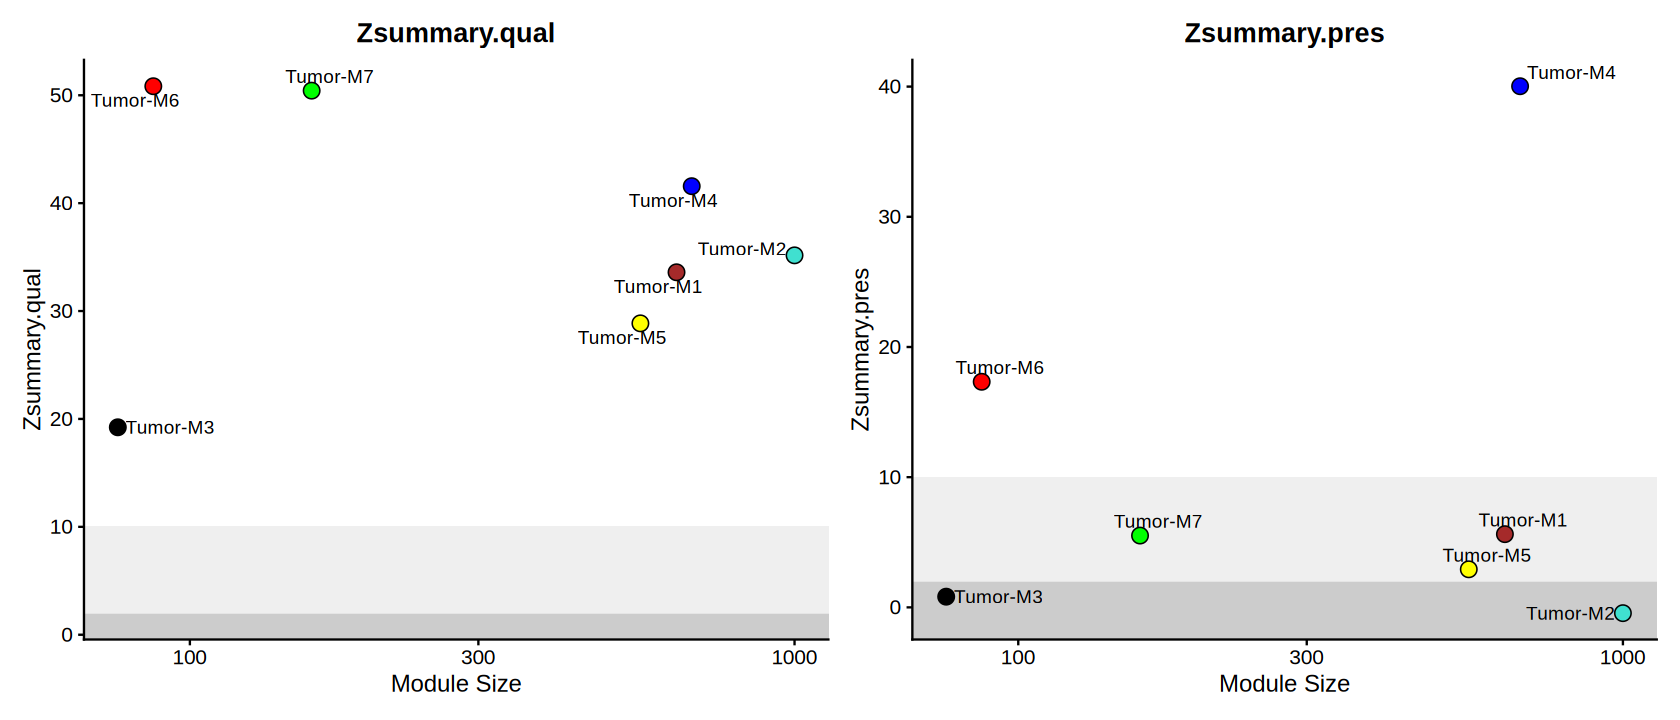

In [17]:
plot_list <- PlotModulePreservation(
  seurat_query,
  name="HGSOC-Tumor",
  statistics = "summary"
)

wrap_plots(plot_list, ncol=2)

Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


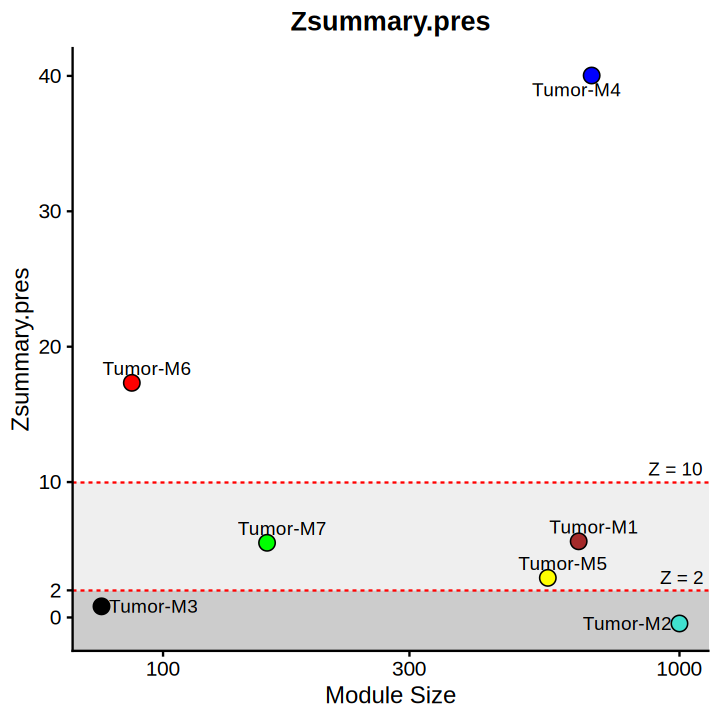

In [27]:
options(repr.plot.height = 6, repr.plot.width = 6)

plot_list$Zsummary.pres +
  geom_hline(
    yintercept = c(2, 10),
    linetype = "dashed",
    linewidth = 0.5,
    color = "red"

  ) +
  scale_y_continuous(
    breaks = c(0, 2,  10, 20, 30, 40)
  ) +
  annotate(
    "text",
    x = Inf, y = 2,
    label = "Z = 2",
    hjust = 1.1,
    vjust = -0.5
  ) +
  annotate(
    "text",
    x = Inf, y = 10,
    label = "Z = 10",
    hjust = 1.1,
    vjust = -0.5
  )

In [32]:
options(repr.plot.height = 6, repr.plot.width = 14)

## Save the plot
png(filename = "./results/PRJCA005422_module_preservation.png", width = 1800, height = 1600, res = 300)

plot_list$Zsummary.pres +
  geom_hline(
    yintercept = c(2, 10),
    linetype = "dashed",
    linewidth = 0.5,
    color = "red"

  ) +
  scale_y_continuous(
    breaks = c(0, 2,  10, 20, 30, 40)
  ) +
  annotate(
    "text",
    x = Inf, y = 2,
    label = "Z = 2",
    hjust = 1.1,
    vjust = -0.5
  ) +
  annotate(
    "text",
    x = Inf, y = 10,
    label = "Z = 10",
    hjust = 1.1,
    vjust = -0.5
  )

dev.off()

Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


pdf 
  2